In [1]:
# Remove the unecessary columns 
import pandas as pd

crime_df = pd.read_csv("../data/dc_crime_merged.csv")

crime_df.head()

,Unnamed: 0,X,Y,CCN,REPORT_DAT,START_DATE,END_DATE,BLOCK,OFFENSE,METHOD,...,BLOCK_GROUP,CENSUS_TRACT,VOTING_PRECINCT,BID,XBLOCK,YBLOCK,LATITUDE,LONGITUDE,OBJECTID,OCTO_RECORD_ID
0,1,399337.0100,138221.0900,21151970,2024/06/20 04:00:00+00,2021/10/19 01:53:00+00,2021/10/19 07:56:00+00,2 - 99 BLOCK OF QUINCY PLACE NE,HOMICIDE,GUN,...,008701 1,8701.0,Precinct 75,NaN,399337.010000,138221.09000,38.911853,-77.007644,894892853,NaN
1,2,400891.3397,131932.5347,22065374,2024/05/22 04:00:00+00,2022/05/10 13:30:00+00,2022/05/10 14:15:00+00,2400 - 2699 BLOCK OF POMEROY ROAD SE,HOMICIDE,GUN,...,007406 2,7406.0,Precinct 118,NaN,400891.339743,131932.53468,38.855203,-76.989731,894897129,NaN
2,3,397576.9900,143086.8500,20160181,2024/05/22 04:00:00+00,2020/11/09 02:03:53+00,2020/11/09 02:20:49+00,5401 - 5499 BLOCK OF GEORGIA AVENUE NW,HOMICIDE,GUN,...,002101 5,2101.0,Precinct 56,NaN,397576.990000,143086.85000,38.955682,-77.027955,895135025,NaN
3,4,398905.1800,143187.0800,24006986,2024/01/14 18:57:38+00,2024/01/14 17:58:00+00,2024/01/14 18:26:00+00,100 - 199 BLOCK OF KENNEDY STREET NW,THEFT/OTHER,OTHERS,...,002102 3,2102.0,Precinct 57,NaN,398905.180000,143187.08000,38.956588,-77.012631,895136149,NaN
4,5,401183.0500,132940.4800,24007103,2024/01/14 23:10:08+00,2024/01/14 22:25:00+00,NaN,1327 - 1399 BLOCK OF W STREET SE,THEFT/OTHER,OTHERS,...,007503 2,7503.0,Precinct 114,NaN,401183.050000,132940.48000,38.864283,-76.986368,895136150,NaN


In [2]:
clean_df = crime_df[['START_DATE', 'OFFENSE', 'SHIFT']]

In [3]:
clean_df.info()
clean_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 55825 entries, 0 to 55824
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   START_DATE  55820 non-null  str  
 1   OFFENSE     55825 non-null  str  
 2   SHIFT       55825 non-null  str  
dtypes: str(3)
memory usage: 1.3 MB


,START_DATE,OFFENSE,SHIFT
0,2021/10/19 01:53:00+00,HOMICIDE,MIDNIGHT
1,2022/05/10 13:30:00+00,HOMICIDE,MIDNIGHT
2,2020/11/09 02:03:53+00,HOMICIDE,MIDNIGHT
3,2024/01/14 17:58:00+00,THEFT/OTHER,DAY
4,2024/01/14 22:25:00+00,THEFT/OTHER,EVENING


In [4]:
clean_df.to_csv("../data/dc_crime_cleaned.csv", index=False)

In [5]:
# Start of Analysis Plan

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

DATA_PATH = "../data/dc_crime_cleaned.csv"
OUTPUT_DIR = "../output"

os.makedirs(OUTPUT_DIR, exist_ok=True)

crime_df = pd.read_csv(DATA_PATH)

crime_df.head()

,START_DATE,OFFENSE,SHIFT
0,2021/10/19 01:53:00+00,HOMICIDE,MIDNIGHT
1,2022/05/10 13:30:00+00,HOMICIDE,MIDNIGHT
2,2020/11/09 02:03:53+00,HOMICIDE,MIDNIGHT
3,2024/01/14 17:58:00+00,THEFT/OTHER,DAY
4,2024/01/14 22:25:00+00,THEFT/OTHER,EVENING


In [6]:
# Convert START_DATE to Datetinme

crime_df['START_DATE'] = pd.to_datetime(crime_df['START_DATE'], errors='coerce')

crime_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 55825 entries, 0 to 55824
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   START_DATE  55820 non-null  datetime64[us, UTC]
 1   OFFENSE     55825 non-null  str                
 2   SHIFT       55825 non-null  str                
dtypes: datetime64[us, UTC](1), str(2)
memory usage: 1.3 MB


In [7]:
crime_df = crime_df.dropna(subset=['START_DATE'])
# 5 rows are dropped due to missing data

crime_df.info()

<class 'pandas.DataFrame'>
Index: 55820 entries, 0 to 55824
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   START_DATE  55820 non-null  datetime64[us, UTC]
 1   OFFENSE     55820 non-null  str                
 2   SHIFT       55820 non-null  str                
dtypes: datetime64[us, UTC](1), str(2)
memory usage: 1.7 MB


In [8]:
crime_df['month'] = crime_df['START_DATE'].dt.month

In [9]:
# Season Variable 

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

crime_df['season'] = crime_df['month'].apply(get_season)

crime_df['season'].value_counts()

season
Winter    14879
Summer    14215
Fall      13589
Spring    13137
Name: count, dtype: int64

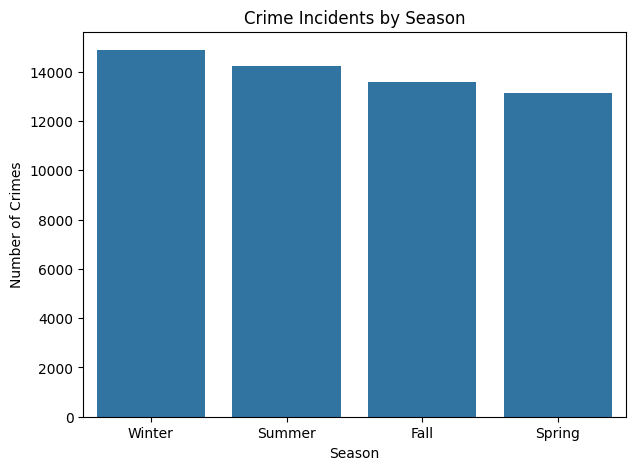

In [10]:
# Crime Incidents by Season 
season_counts = crime_df['season'].value_counts()

plt.figure(figsize=(7,5))
sns.barplot(x=season_counts.index, y=season_counts.values)

plt.title("Crime Incidents by Season")
plt.xlabel("Season")
plt.ylabel("Number of Crimes")

plt.savefig("../output/crime_by_season.png", dpi=300, bbox_inches="tight")

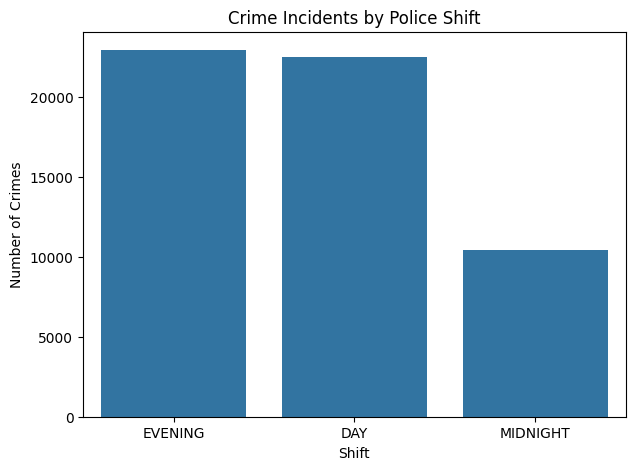

In [11]:
# Crime Incidents by Shift
shift_counts = crime_df['SHIFT'].value_counts()

plt.figure(figsize=(7,5))
sns.barplot(x=shift_counts.index, y=shift_counts.values)

plt.title("Crime Incidents by Police Shift")
plt.xlabel("Shift")
plt.ylabel("Number of Crimes")

plt.savefig("../output/crime_by_shift.png", dpi=300, bbox_inches="tight")

plt.show()

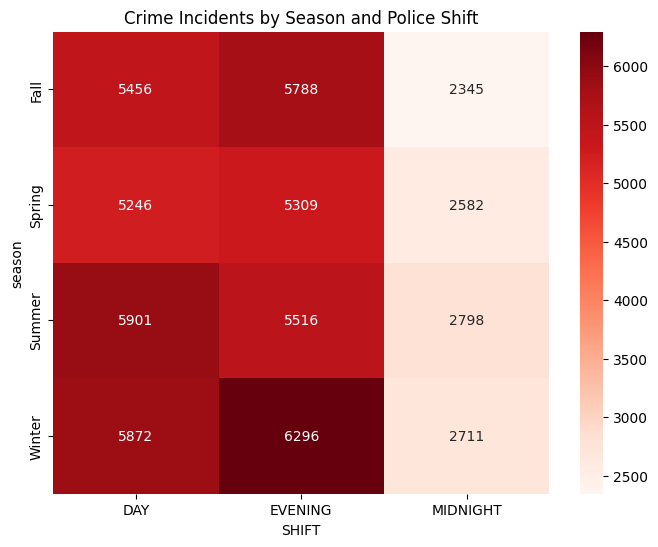

In [12]:
# HeatMap for both Crime and Season 

season_shift = crime_df.groupby(['season','SHIFT']).size().unstack()

plt.figure(figsize=(8,6))
sns.heatmap(season_shift, annot=True, fmt="d", cmap="Reds")

plt.title("Crime Incidents by Season and Police Shift")

plt.savefig("../output/crime_season_shift_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

In [13]:
from scipy.stats import ttest_ind

summer = crime_df[crime_df['season'] == "Summer"]
winter = crime_df[crime_df['season'] == "Winter"]

summer_daily = summer.groupby(summer['START_DATE'].dt.date).size()
winter_daily = winter.groupby(winter['START_DATE'].dt.date).size()

t_stat, p_val = ttest_ind(summer_daily, winter_daily)

print("T-statistic:", t_stat)
print("P-value:", p_val)

T-statistic: 5.198233472928257
P-value: 2.9990204732942503e-07


In [14]:
summer_daily.mean(), winter_daily.mean()

(np.float64(68.34134615384616), np.float64(55.72659176029963))

In [15]:
# Which crime is most popular in the highest combination?
season_shift_counts = crime_df.groupby(['season', 'SHIFT']).size().reset_index(name='crime_count')

max_row = season_shift_counts.loc[season_shift_counts['crime_count'].idxmax()]

max_season = max_row['season']
max_shift = max_row['SHIFT']

print("Highest Crime Combination:")
print(max_row)

# Step 3: Filter dataset for that combination
filtered_df = crime_df[(crime_df['season'] == max_season) & (crime_df['SHIFT'] == max_shift)]

# Step 4: Find most common offense
top_offense = filtered_df['OFFENSE'].value_counts().idxmax()
top_count = filtered_df['OFFENSE'].value_counts().max()

print("Most Common Crime in This Combination:")
print("Offense:", top_offense)
print("Count:", top_count)

Highest Crime Combination:
season          Winter
SHIFT          EVENING
crime_count       6296
Name: 10, dtype: object
Most Common Crime in This Combination:
Offense: THEFT/OTHER
Count: 3089


In [16]:
top5_offenses = crime_df['OFFENSE'].value_counts().head(5)

print(top5_offenses)

OFFENSE
THEFT/OTHER                   25861
THEFT F/AUTO                  12574
MOTOR VEHICLE THEFT            9358
ROBBERY                        3566
ASSAULT W/DANGEROUS WEAPON     2072
Name: count, dtype: int64


In [20]:
top_offenses = [
    "THEFT/OTHER",
    "THEFT F/AUTO",
    "MOTOR VEHICLE THEFT",
    "ROBBERY",
    "ASSAULT W/DANGEROUS WEAPON"
]

offense_season_shift = (
    crime_df[crime_df['OFFENSE'].isin(top_offenses)]
    .groupby(['OFFENSE', 'season', 'SHIFT'])
    .size()
    .reset_index(name='crime_count')
)

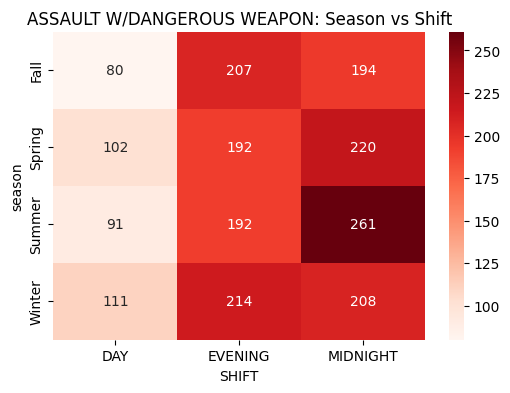

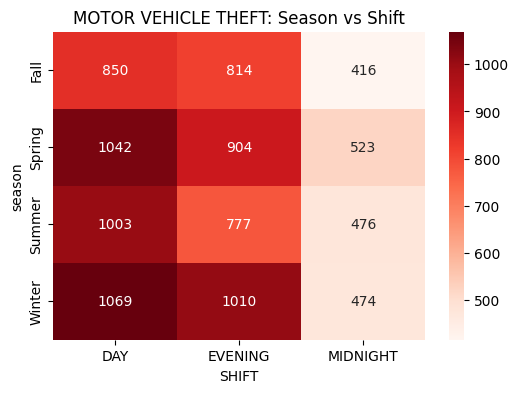

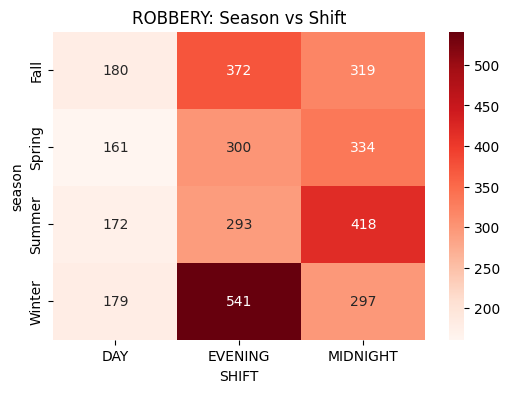

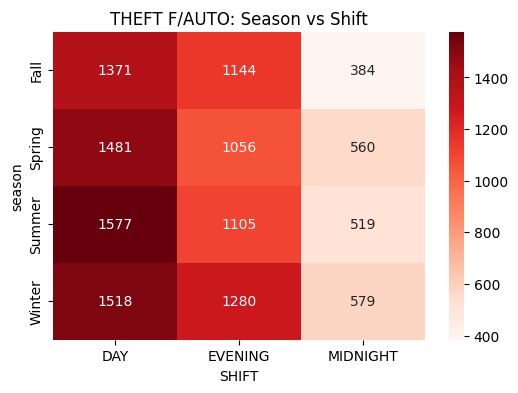

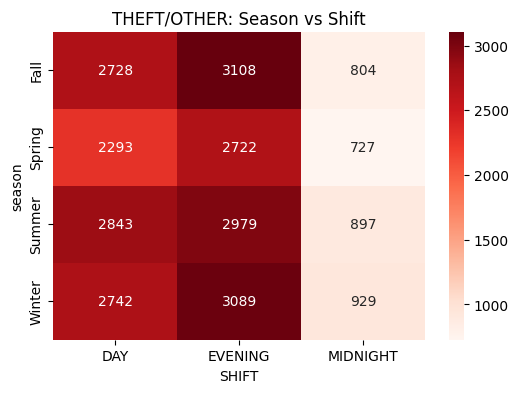

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

offenses = offense_season_shift['OFFENSE'].unique()

for offense in offenses:
    
    subset = offense_season_shift[offense_season_shift['OFFENSE'] == offense]
    
    pivot = subset.pivot(index='season', columns='SHIFT', values='crime_count')
    
    plt.figure(figsize=(6,4))
    sns.heatmap(pivot, annot=True, fmt="d", cmap="Reds")
    
    plt.title(f"{offense}: Season vs Shift")
    
    plt.savefig(f"../output/{offense.replace('/','_')}_heatmap.png",
                dpi=300, bbox_inches="tight")
    
    plt.show()

In [23]:
top_combos = offense_season_shift.loc[
    offense_season_shift.groupby("OFFENSE")["crime_count"].idxmax()
]

print(top_combos)

                       OFFENSE  season     SHIFT  crime_count
8   ASSAULT W/DANGEROUS WEAPON  Summer  MIDNIGHT          261
21         MOTOR VEHICLE THEFT  Winter       DAY         1069
34                     ROBBERY  Winter   EVENING          541
42                THEFT F/AUTO  Summer       DAY         1577
49                 THEFT/OTHER    Fall   EVENING         3108
